# Electrostatics of the 84 bound complexes

APBS surface potentials, monomer decomposition, and screened approach curves.
Figures are written to `~/Documents/apbs_electrostatics_84_targets/figures/`.

In [1]:
import os
from pathlib import Path

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("~/Documents/apbs_electrostatics_84_targets").expanduser()
APPROACH = DATA / "approach"
FIGURES = DATA / "figures"
FIGURES.mkdir(exist_ok=True)

# Computer Modern via matplotlib's bundled cmr10, so this does not need a
# LaTeX install. cmr10 has no unicode minus glyph, hence the two axes settings.
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(FIGURES / f"{name}.{ext}")
    print("wrote", name)

KT = 0.5925  # kcal/mol at 298.15 K

In [2]:
summary = pd.read_csv(APPROACH / "approach_summary.csv")
DEBYE = float(summary.debye_length_angstrom.iloc[0])
print(f"{len(summary)} dimers, Debye length {DEBYE:.2f} A")
summary.head(3)[["complex_id", "moving_chain", "fixed_chain",
                 "energy_bound_kcal_per_mol", "path_mode"]]

84 dimers, Debye length 7.86 A


,complex_id,moving_chain,fixed_chain,energy_bound_kcal_per_mol,path_mode
0,1acb,I,E,-1.3685,linear
1,1ay7,B,A,-2.9075,linear
2,1c3a,B,A,-2.7059,steered


## 1. Surface potentials reproduce residue charge

In [3]:
store = DATA / "targets_84_apbs_surface.hdf5"
rows = []
with h5py.File(store, "r") as handle:
    for model in handle:
        group = handle[model]
        exposed = group["residue_surface_point_count"][:] > 0
        rows.append(pd.DataFrame({
            "model": model,
            "name": group["residue_name"].asstr()[:][exposed],
            "charge": group["residue_charge"][:][exposed],
            "potential": group["residue_potential_mean"][:][exposed],
            "sasa": group["residue_sasa"][:][exposed],
        }))
residues = pd.concat(rows, ignore_index=True)
residues = residues[np.isfinite(residues.potential)]
print(f"{len(residues):,} solvent-exposed residues")

22,689 solvent-exposed residues


wrote fig1_residue_validation
ARG/LYS +1.03, ASP/GLU -1.75 kT/e
correlation positive in 84/84 complexes, min 0.11


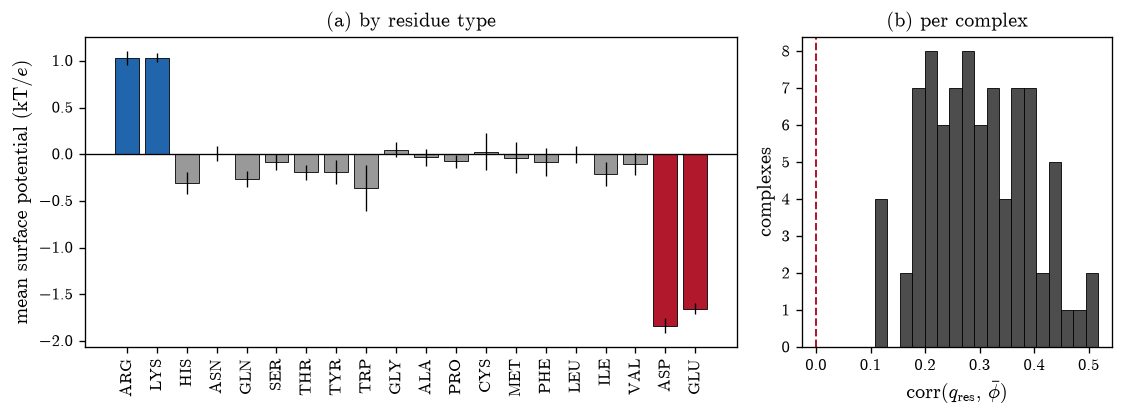

In [4]:
order = ["ARG", "LYS", "HIS", "ASN", "GLN", "SER", "THR", "TYR", "TRP",
         "GLY", "ALA", "PRO", "CYS", "MET", "PHE", "LEU", "ILE", "VAL",
         "ASP", "GLU"]
stats = residues.groupby("name").potential.agg(["mean", "sem", "size"]).reindex(order)
charge_of = residues.groupby("name").charge.median().reindex(order)
colour = ["#2166ac" if c > 0.5 else "#b2182b" if c < -0.5 else "#999999" for c in charge_of]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6),
                         gridspec_kw={"width_ratios": [2.1, 1]})
ax = axes[0]
ax.bar(range(len(order)), stats["mean"], yerr=stats["sem"], color=colour,
       edgecolor="black", linewidth=0.5, error_kw={"lw": 0.8})
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=90)
ax.set_ylabel(r"mean surface potential (kT/$e$)")
ax.set_title("(a) by residue type")

# Per-model correlation between formal charge and surface potential.
correlation = residues.groupby("model").apply(
    lambda d: np.corrcoef(d.charge, d.potential)[0, 1], include_groups=False)
ax = axes[1]
ax.hist(correlation, bins=18, color="#4d4d4d", edgecolor="black", linewidth=0.5)
ax.axvline(0, color="#b2182b", lw=1.2, ls="--")
ax.set_xlabel(r"corr($q_{\mathrm{res}}$, $\bar{\phi}$)")
ax.set_ylabel("complexes")
ax.set_title("(b) per complex")
fig.tight_layout()
save(fig, "fig1_residue_validation")

print(f"ARG/LYS {stats.loc[['ARG','LYS'],'mean'].mean():+.2f}, "
      f"ASP/GLU {stats.loc[['ASP','GLU'],'mean'].mean():+.2f} kT/e")
print(f"correlation positive in {int((correlation > 0).sum())}/{len(correlation)} complexes, "
      f"min {correlation.min():.2f}")

## 2. Distribution of surface potential by formal charge

wrote fig2_potential_distribution


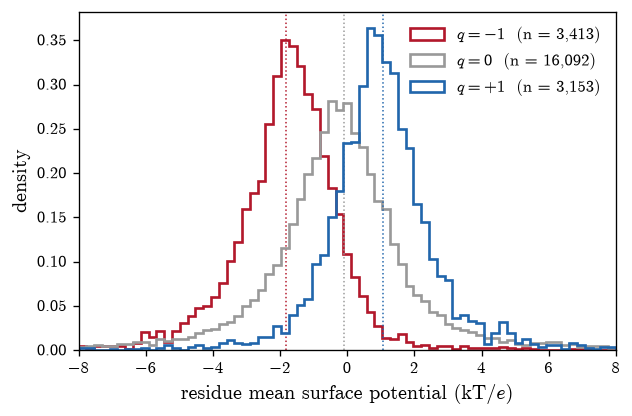

In [5]:
fig, ax = plt.subplots(figsize=(5.4, 3.6))
groups = [(-1, "#b2182b", r"$q = -1$"), (0, "#999999", r"$q = 0$"), (1, "#2166ac", r"$q = +1$")]
bins = np.linspace(-8, 8, 70)
for value, colour_, label in groups:
    subset = residues[np.isclose(residues.charge, value, atol=0.25)].potential
    ax.hist(subset, bins=bins, density=True, histtype="step", lw=1.6,
            color=colour_, label=f"{label}  (n = {len(subset):,})")
    ax.axvline(subset.mean(), color=colour_, lw=0.9, ls=":")
ax.set_xlabel(r"residue mean surface potential (kT/$e$)")
ax.set_ylabel("density")
ax.legend(frameon=False)
ax.set_xlim(-8, 8)
fig.tight_layout()
save(fig, "fig2_potential_distribution")

## 3. Interaction potential is confined to the interface

$\Delta\phi = \phi_{\mathrm{complex}} - \sum_{\mathrm{chains}} \phi_{\mathrm{chain}}$, on the shared grid.
Because the monomers inherit the complex's charges, the Coulomb part cancels and
what is left is the change in the dielectric and ionic boundary on binding.

In [6]:
from scipy.spatial import cKDTree

monomers = DATA / "targets_84_monomers_apbs_surface.hdf5"
bands = [(0, 4), (4, 6), (6, 8), (8, 12), (12, 20), (20, 40)]
examples = ["1acb", "1ugh", "2grn", "1ay7"]
profile = {}

with h5py.File(store, "r") as complexes, h5py.File(monomers, "r") as chains:
    for model in examples:
        group = complexes[model]
        parts = [name for name in chains
                 if chains[name].attrs.get("parent_complex_id") == model]
        delta = group["potential_grid"][:].astype(np.float64)
        for part in parts:
            delta -= chains[part]["potential_grid"][:]

        origin = np.asarray(group.attrs["grid_origin"])
        spacing = np.asarray(group.attrs["grid_spacing"])
        chain_id = group["atom_chain"].asstr()[:]
        labels = sorted(set(chain_id))
        trees = [cKDTree(group["atom_xyz"][:][chain_id == c]) for c in labels]

        rng = np.random.default_rng(0)
        flat = rng.choice(delta.size, 250_000, replace=False)
        index = np.stack(np.unravel_index(flat, delta.shape), axis=1)
        points = origin + index * spacing
        # Distance from the contact zone: small only where a voxel is close to
        # both chains at once.
        contact = np.maximum(trees[0].query(points)[0], trees[1].query(points)[0])
        values = np.abs(delta[index[:, 0], index[:, 1], index[:, 2]])
        profile[model] = [np.median(values[(contact >= lo) & (contact < hi)])
                          for lo, hi in bands]
        print(model, "done")

1acb done


1ugh done


2grn done


1ay7 done


wrote fig3_interaction_localisation
1acb: 3.53 kT/e at contact -> 0.0065 beyond 20 A (542x)
1ugh: 4.31 kT/e at contact -> 0.0062 beyond 20 A (692x)
2grn: 2.35 kT/e at contact -> 0.0051 beyond 20 A (458x)
1ay7: 3.65 kT/e at contact -> 0.0178 beyond 20 A (205x)


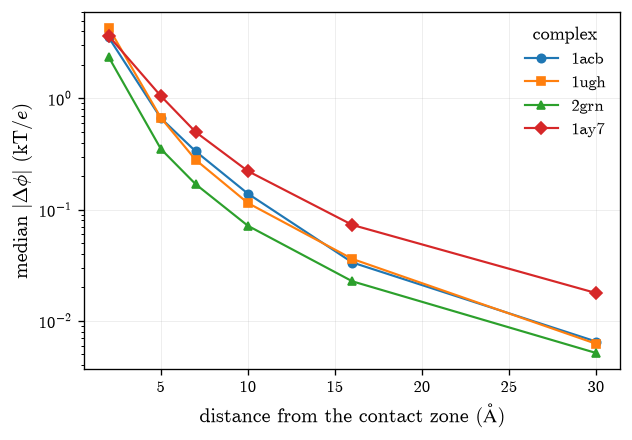

In [7]:
centres = [np.mean(b) for b in bands]
fig, ax = plt.subplots(figsize=(5.4, 3.8))
markers = ["o", "s", "^", "D"]
for (model, values), marker in zip(profile.items(), markers):
    ax.semilogy(centres, values, marker=marker, ms=5, lw=1.3, label=model)
ax.set_xlabel(r"distance from the contact zone ($\mathrm{\AA}$)")
ax.set_ylabel(r"median $|\Delta\phi|$ (kT/$e$)")
ax.legend(frameon=False, title="complex")
ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout()
save(fig, "fig3_interaction_localisation")

for model, values in profile.items():
    print(f"{model}: {values[0]:.2f} kT/e at contact -> {values[-1]:.4f} beyond 20 A "
          f"({values[0]/values[-1]:.0f}x)")

## 4. Approach curves

wrote fig4_approach_curves
attractive at contact: 84/84
median -3.62 kcal/mol (-6.1 kT), range -15.41 to -0.00


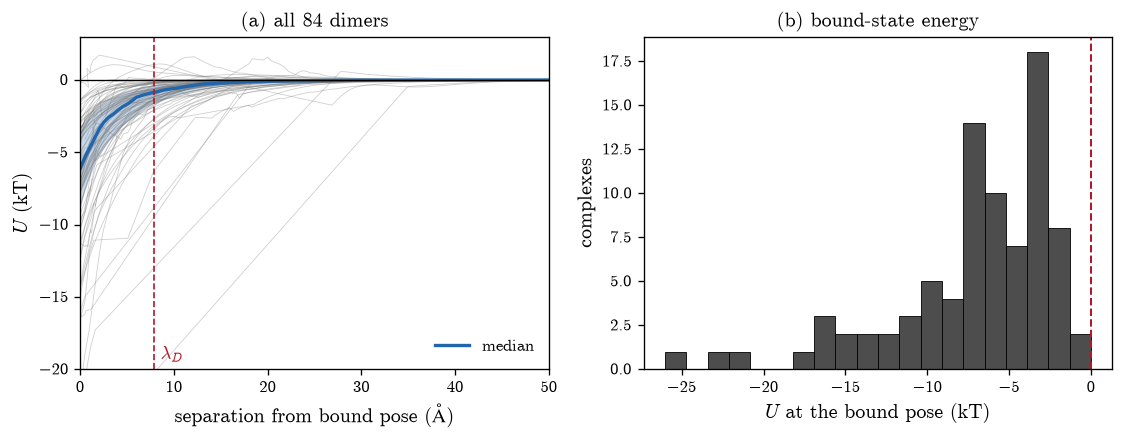

In [8]:
curves = {}
for model in summary.complex_id:
    frame = pd.read_csv(APPROACH / f"{model}_approach.csv")
    curves[model] = frame

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
ax = axes[0]
for model, frame in curves.items():
    clean = frame[~frame.steric_overlap]
    ax.plot(clean.displacement_angstrom, clean.interaction_energy_kT,
            color="#777777", lw=0.5, alpha=0.35)

grid = np.arange(0, 50.5, 0.5)
stack = []
for frame in curves.values():
    clean = frame[~frame.steric_overlap].sort_values("displacement_angstrom")
    stack.append(np.interp(grid, clean.displacement_angstrom, clean.interaction_energy_kT,
                           left=np.nan, right=np.nan))
stack = np.array(stack)
median = np.nanmedian(stack, axis=0)
lower = np.nanpercentile(stack, 25, axis=0)
upper = np.nanpercentile(stack, 75, axis=0)
ax.fill_between(grid, lower, upper, color="#2166ac", alpha=0.25, lw=0)
ax.plot(grid, median, color="#2166ac", lw=2, label="median")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(DEBYE, color="#b2182b", ls="--", lw=1)
ax.annotate(r"$\lambda_D$", xy=(DEBYE, 0), xycoords=("data", "axes fraction"),
            xytext=(4, 6), textcoords="offset points", color="#b2182b")
ax.set_xlabel(r"separation from bound pose ($\mathrm{\AA}$)")
ax.set_ylabel(r"$U$ (kT)")
ax.set_xlim(0, 50)
ax.set_ylim(-20, 3)
ax.legend(frameon=False, loc="lower right")
ax.set_title("(a) all 84 dimers")

ax = axes[1]
ax.hist(summary.energy_bound_kT, bins=20, color="#4d4d4d",
        edgecolor="black", linewidth=0.5)
ax.axvline(0, color="#b2182b", lw=1.2, ls="--")
ax.set_xlabel(r"$U$ at the bound pose (kT)")
ax.set_ylabel("complexes")
ax.set_title("(b) bound-state energy")
fig.tight_layout()
save(fig, "fig4_approach_curves")

print(f"attractive at contact: {(summary.energy_bound_kcal_per_mol < 0).sum()}/84")
print(f"median {summary.energy_bound_kcal_per_mol.median():.2f} kcal/mol "
      f"({summary.energy_bound_kT.median():.1f} kT), "
      f"range {summary.energy_bound_kcal_per_mol.min():.2f} to "
      f"{summary.energy_bound_kcal_per_mol.max():.2f}")

## 5. Effect of screening

wrote fig5_screening
screened/unscreened where both have the same sign: median 0.76 (n = 77)


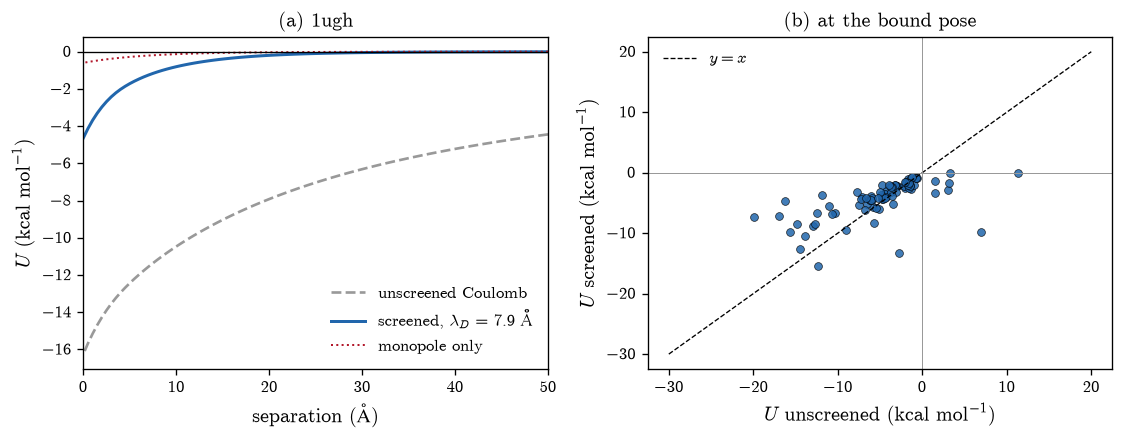

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

ax = axes[0]
example = curves["1ugh"]
clean = example[~example.steric_overlap]
ax.plot(clean.displacement_angstrom, clean.interaction_energy_unscreened_kcal_per_mol,
        lw=1.6, color="#999999", ls="--", label="unscreened Coulomb")
ax.plot(clean.displacement_angstrom, clean.interaction_energy_kcal_per_mol,
        lw=1.8, color="#2166ac", label=r"screened, $\lambda_D$ = " + f"{DEBYE:.1f}" + r" $\mathrm{\AA}$")
ax.plot(clean.displacement_angstrom, clean.monopole_energy_kcal_per_mol,
        lw=1.2, color="#b2182b", ls=":", label="monopole only")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel(r"separation ($\mathrm{\AA}$)")
ax.set_ylabel(r"$U$ (kcal mol$^{-1}$)")
ax.set_title("(a) 1ugh")
ax.legend(frameon=False)
ax.set_xlim(0, 50)

ax = axes[1]
ax.scatter(summary.energy_unscreened_bound_kcal_per_mol,
           summary.energy_bound_kcal_per_mol, s=22, color="#2166ac",
           edgecolor="black", linewidth=0.4, alpha=0.85)
limits = [-30, 20]
ax.plot(limits, limits, color="black", lw=0.8, ls="--", label=r"$y = x$")
ax.axhline(0, color="#999999", lw=0.6)
ax.axvline(0, color="#999999", lw=0.6)
ax.set_xlabel(r"$U$ unscreened (kcal mol$^{-1}$)")
ax.set_ylabel(r"$U$ screened (kcal mol$^{-1}$)")
ax.set_title("(b) at the bound pose")
ax.legend(frameon=False)
fig.tight_layout()
save(fig, "fig5_screening")

ratio = (summary.energy_bound_kcal_per_mol /
         summary.energy_unscreened_bound_kcal_per_mol)
same_sign = summary.energy_bound_kcal_per_mol * summary.energy_unscreened_bound_kcal_per_mol > 0
print(f"screened/unscreened where both have the same sign: median {ratio[same_sign].median():.2f} "
      f"(n = {same_sign.sum()})")

## 6. Range of the interaction, and sign reversals

wrote fig6_range_and_signflips
onset: median 11.0 A = 1.4 Debye lengths
sign reversals: 16/84


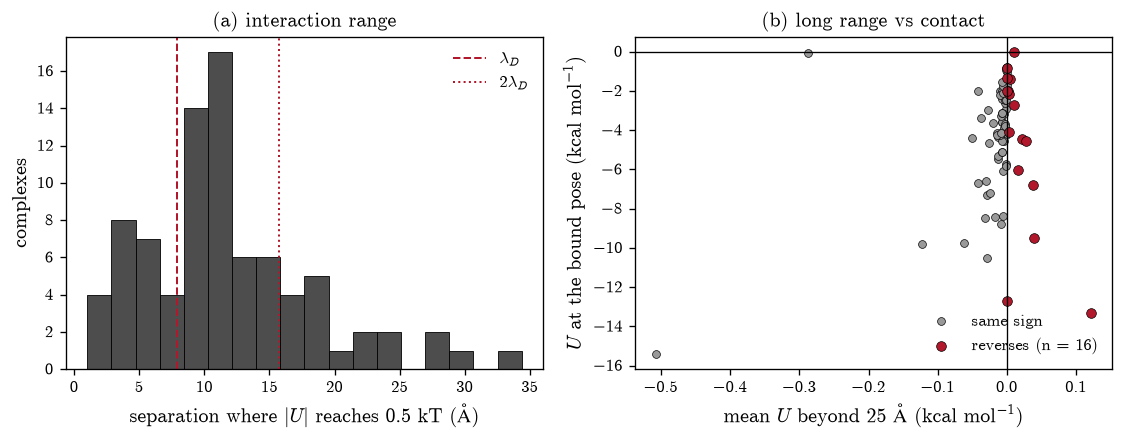

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

ax = axes[0]
onset = pd.to_numeric(summary.onset_displacement_angstrom, errors="coerce").dropna()
ax.hist(onset, bins=18, color="#4d4d4d", edgecolor="black", linewidth=0.5)
for multiple, style in ((1, "--"), (2, ":")):
    ax.axvline(multiple * DEBYE, color="#b2182b", ls=style, lw=1.2,
               label=rf"${multiple if multiple > 1 else ''}\lambda_D$")
ax.set_xlabel(r"separation where $|U|$ reaches 0.5 kT ($\mathrm{\AA}$)")
ax.set_ylabel("complexes")
ax.legend(frameon=False)
ax.set_title("(a) interaction range")

ax = axes[1]
long_range = np.array([curves[m][curves[m].displacement_angstrom > 25]
                       .interaction_energy_kcal_per_mol.mean() for m in summary.complex_id])
product = (summary.moving_net_charge * summary.fixed_net_charge).to_numpy()
flips = summary.sign_flips_on_approach.to_numpy()
ax.scatter(long_range[~flips], summary.energy_bound_kcal_per_mol[~flips],
           s=22, color="#999999", edgecolor="black", linewidth=0.4, label="same sign")
ax.scatter(long_range[flips], summary.energy_bound_kcal_per_mol[flips],
           s=34, color="#b2182b", edgecolor="black", linewidth=0.4,
           label=f"reverses (n = {int(flips.sum())})")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(r"mean $U$ beyond 25 $\mathrm{\AA}$ (kcal mol$^{-1}$)")
ax.set_ylabel(r"$U$ at the bound pose (kcal mol$^{-1}$)")
ax.legend(frameon=False, loc="lower right")
ax.set_title("(b) long range vs contact")
fig.tight_layout()
save(fig, "fig6_range_and_signflips")

print(f"onset: median {onset.median():.1f} A = {onset.median()/DEBYE:.1f} Debye lengths")
print(f"sign reversals: {int(flips.sum())}/84")

## 7. Separation paths

wrote fig7_paths
linear 60, steered 24
fully clash free: 50/84
median overlapping frames: 0


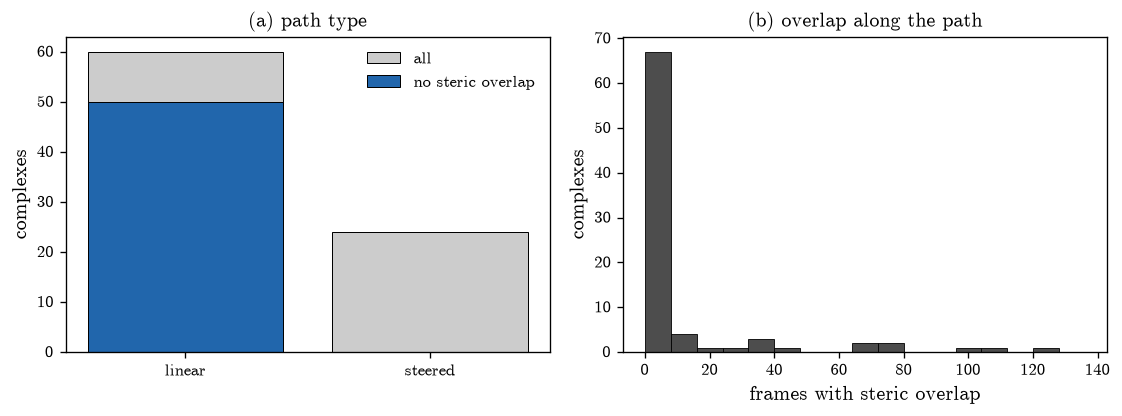

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))

ax = axes[0]
counts = summary.path_mode.value_counts()
clash_free = summary.groupby("path_mode").path_clash_free.sum()
positions = np.arange(len(counts))
ax.bar(positions, counts.values, color="#cccccc", edgecolor="black",
       linewidth=0.6, label="all")
ax.bar(positions, clash_free.reindex(counts.index).values, color="#2166ac",
       edgecolor="black", linewidth=0.6, label="no steric overlap")
ax.set_xticks(positions)
ax.set_xticklabels(counts.index)
ax.set_ylabel("complexes")
ax.legend(frameon=False)
ax.set_title("(a) path type")

ax = axes[1]
overlap = summary.frames_with_steric_overlap
ax.hist(overlap, bins=np.arange(0, overlap.max() + 12, 8), color="#4d4d4d",
        edgecolor="black", linewidth=0.5)
ax.set_xlabel("frames with steric overlap")
ax.set_ylabel("complexes")
ax.set_title("(b) overlap along the path")
fig.tight_layout()
save(fig, "fig7_paths")

print(f"linear {int(counts.get('linear', 0))}, steered {int(counts.get('steered', 0))}")
print(f"fully clash free: {int(summary.path_clash_free.sum())}/84")
print(f"median overlapping frames: {overlap.median():.0f}")

## 8. Which residues carry the interaction

wrote fig8_residue_contributions
chain residue_name  residue_number  residue_charge  contribution_kcal_per_mol
    E          LYS             137             1.0                  -1.317892
    I          GLU             249            -1.0                  -1.307659
    E          ARG             195             1.0                  -1.069135
    I          ASP             282            -1.0                  -1.061001
    E          LYS             170             1.0                  -0.579359
    I          GLU             252            -1.0                  -0.537494
    I          ASP             261            -1.0                  -0.473576
    E          SER             166             0.0                  -0.455427
    I          GLU             248            -1.0                  -0.372929
    E          LYS              94             1.0                  -0.310419
    E          GLN              63             0.0                  -0.224951
    E          GLU             

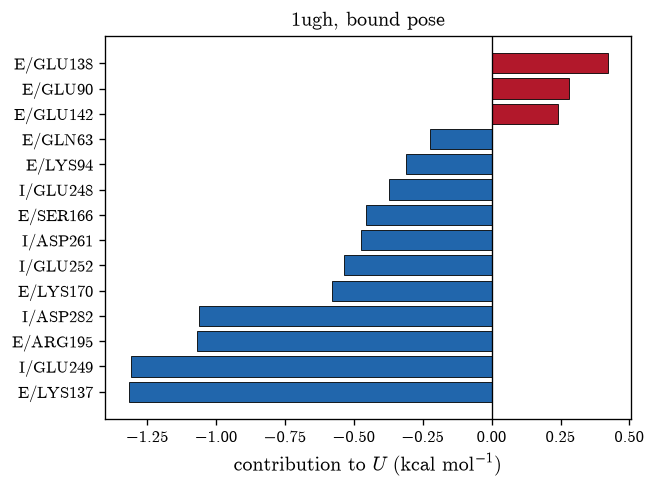

In [12]:
example_id = "1ugh"
detail = pd.read_csv(APPROACH / f"{example_id}_approach_residues.csv")
bound_step = detail.step.max()
contact = detail[(detail.step == bound_step)].copy()
contact["abs"] = contact.contribution_kcal_per_mol.abs()
top = contact.nlargest(14, "abs").sort_values("contribution_kcal_per_mol")

fig, ax = plt.subplots(figsize=(5.6, 4.2))
colours = ["#b2182b" if v > 0 else "#2166ac" for v in top.contribution_kcal_per_mol]
labels = [f"{c}/{n}{int(r)}" for c, n, r in
          zip(top.chain, top.residue_name, top.residue_number)]
ax.barh(range(len(top)), top.contribution_kcal_per_mol, color=colours,
        edgecolor="black", linewidth=0.5)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(r"contribution to $U$ (kcal mol$^{-1}$)")
ax.set_title(f"{example_id}, bound pose")
fig.tight_layout()
save(fig, "fig8_residue_contributions")

print(top[["chain", "residue_name", "residue_number", "residue_charge",
           "contribution_kcal_per_mol"]].to_string(index=False))